In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("Data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
# cheacking the null values
df.isnull().sum()


gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
# checking tha duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# checking tha data types of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [36]:
# checking the value counts for each column
for col in df.columns:
    print(f"\nValue Count for {col}:")
    print(df[col].value_counts())


Value Count for gender:
gender
female    509
male      477
Name: count, dtype: int64

Value Count for race_ethnicity:
race_ethnicity
group C    315
group D    261
group B    183
group E    139
group A     88
Name: count, dtype: int64

Value Count for parental_level_of_education:
parental_level_of_education
some college          222
associate's degree    221
high school           191
some high school      175
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Value Count for lunch:
lunch
standard        642
free/reduced    344
Name: count, dtype: int64

Value Count for test_preparation_course:
test_preparation_course
none         629
completed    357
Name: count, dtype: int64

Value Count for math_score:
math_score
65    36
62    35
69    32
59    32
73    27
      ..
34     2
95     2
29     2
33     1
36     1
Name: count, Length: 71, dtype: int64

Value Count for reading_score:
reading_score
72    34
74    33
64    32
73    30
67    30
      ..
37     3
9

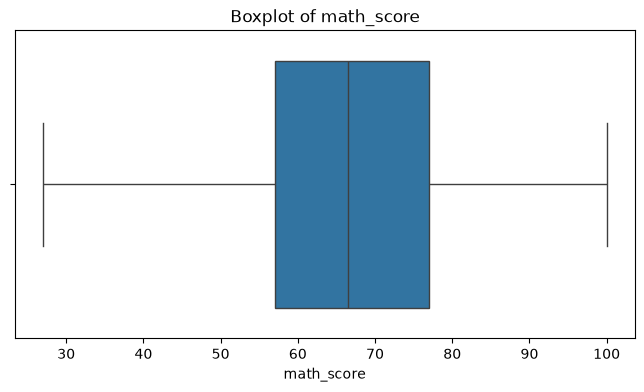

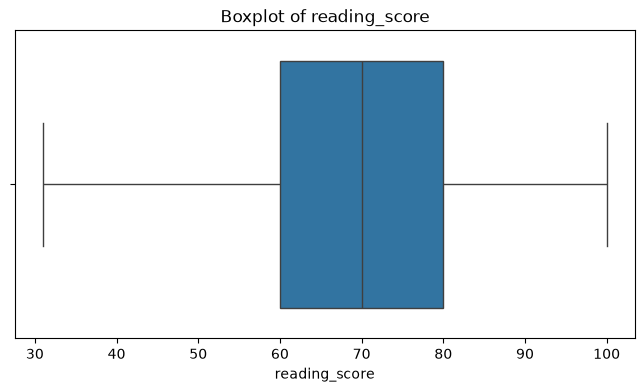

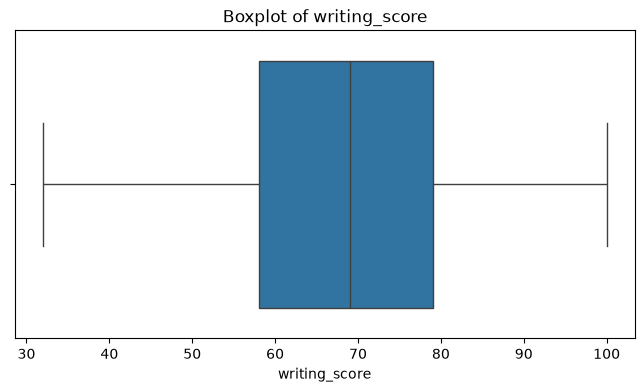

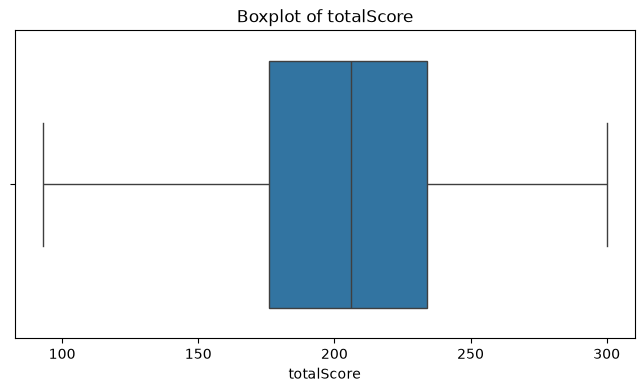

In [37]:
# checking outliers using boxplot
for col in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [38]:
# removing outliers using IQR method
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

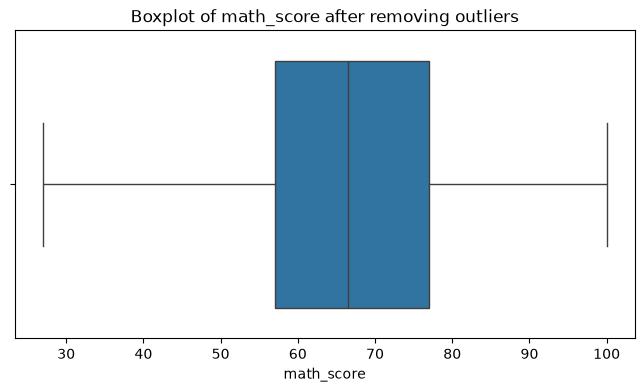

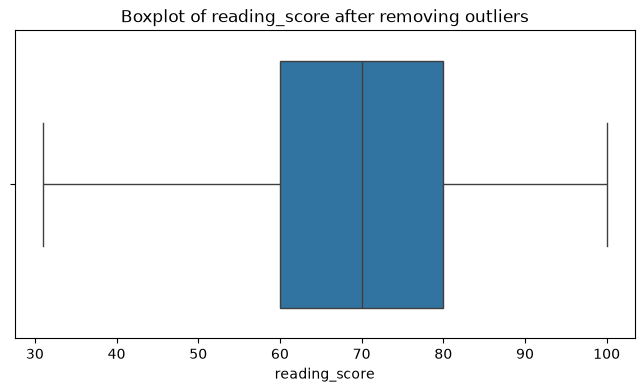

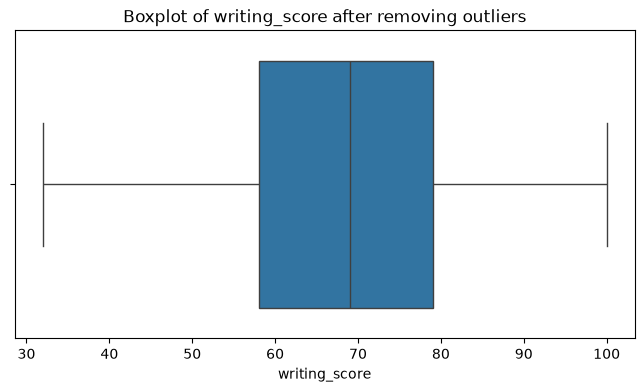

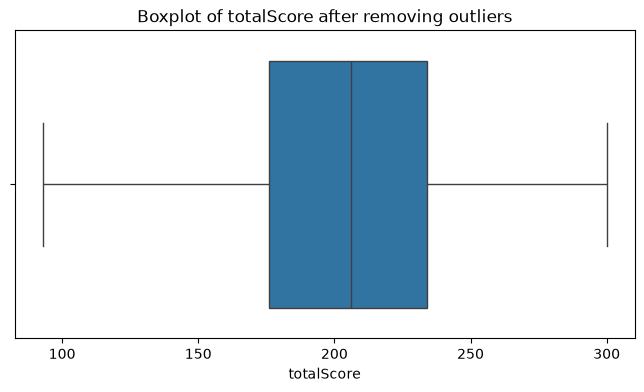

In [39]:
# cheaking the outliers after removing the outliers
for col in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} after removing outliers')
    plt.show()

In [40]:
# adding new column for total marks
df['totalScore'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [41]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,totalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [42]:
# checking male and female students performance
df.groupby('gender')['totalScore'].mean()

gender
female    210.988212
male      198.746331
Name: totalScore, dtype: float64

C:\Users\dell\AppData\Local\Temp\ipykernel_8576\1497927337.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  plot = sns.barplot(x='gender', y='totalScore', data=df, ci=None)


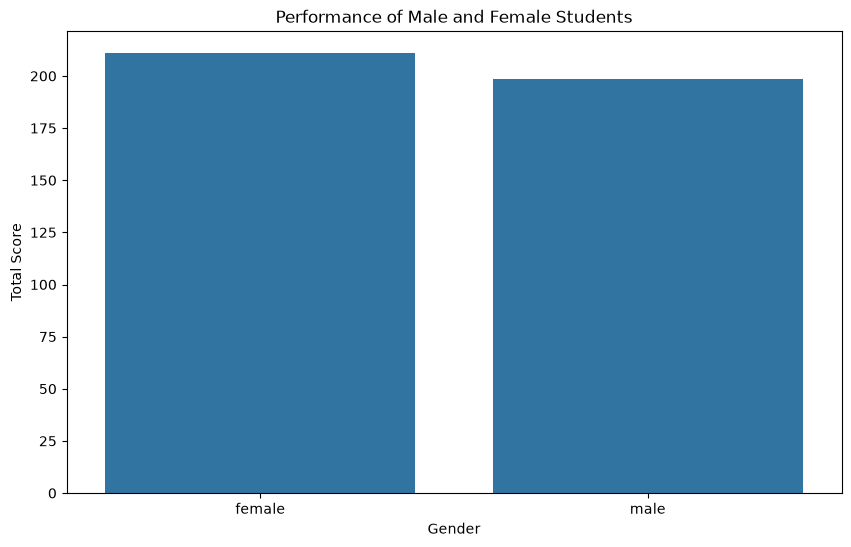

In [43]:
# creating a plot male and female students performance

plt.figure(figsize=(10, 6))
plot = sns.barplot(x='gender', y='totalScore', data=df, ci=None)
plt.title('Performance of Male and Female Students')
plt.xlabel('Gender')
plt.ylabel('Total Score')
plt.show()

In [ ]:
# checking numerical columns categorical columns 

numeric_col=[feature for feature in df.columns if df[feature].dtype != 'str']
categorical_col=[feature for feature in df.columns if df[feature].dtype == 'str']


In [45]:
print (numeric_col)
print(categorical_col)

['math_score', 'reading_score', 'writing_score', 'totalScore']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [54]:
# student count who get full marks in subjects

reading_full=df[df['reading_score']== 100]['reading_score'].count()
math_full=df[df['math_score'] == 100]['math_score'].count()
writing_full=df[df['writing_score'] == 100]['writing_score'].count()

print(f"Number of students who got full marks in reading {reading_full}")
print(f"Number of students who got full marks in math {math_full}")    
print(f"Number of students who got full marks in writing {writing_full}")    

Number of students who got full marks in reading 17
Number of students who got full marks in math 7
Number of students who got full marks in writing 14


In [60]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,totalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [ ]:
# adding new column for average marks

df['avgScore'] = df['totalScore'] / 3

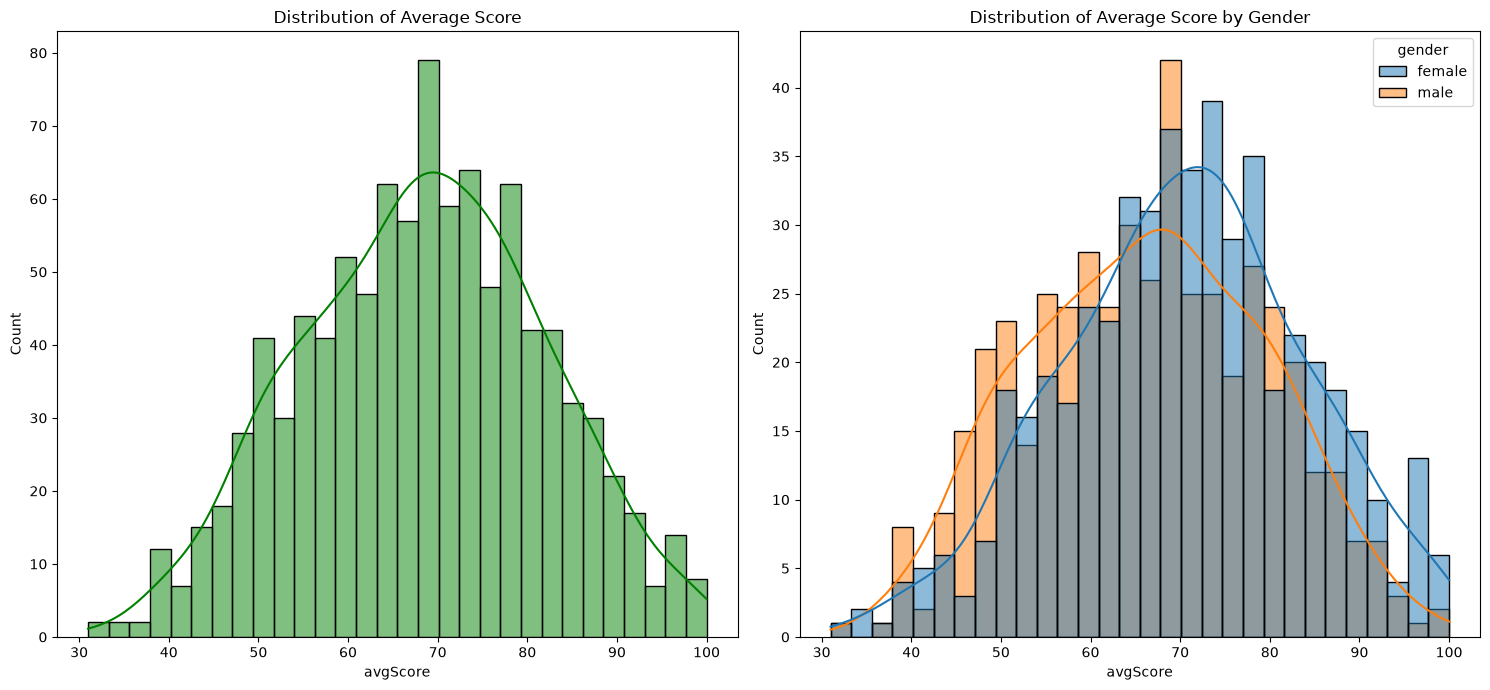

In [64]:
# Visualizing the distribution of average scores

plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='avgScore',kde=True,bins=30,color='green')
plt.title('Distribution of Average Score')

plt.subplot(122)
sns.histplot(data=df,x='avgScore',kde=True,bins=30,hue='gender')
plt.title('Distribution of Average Score by Gender')

plt.tight_layout()
plt.show()

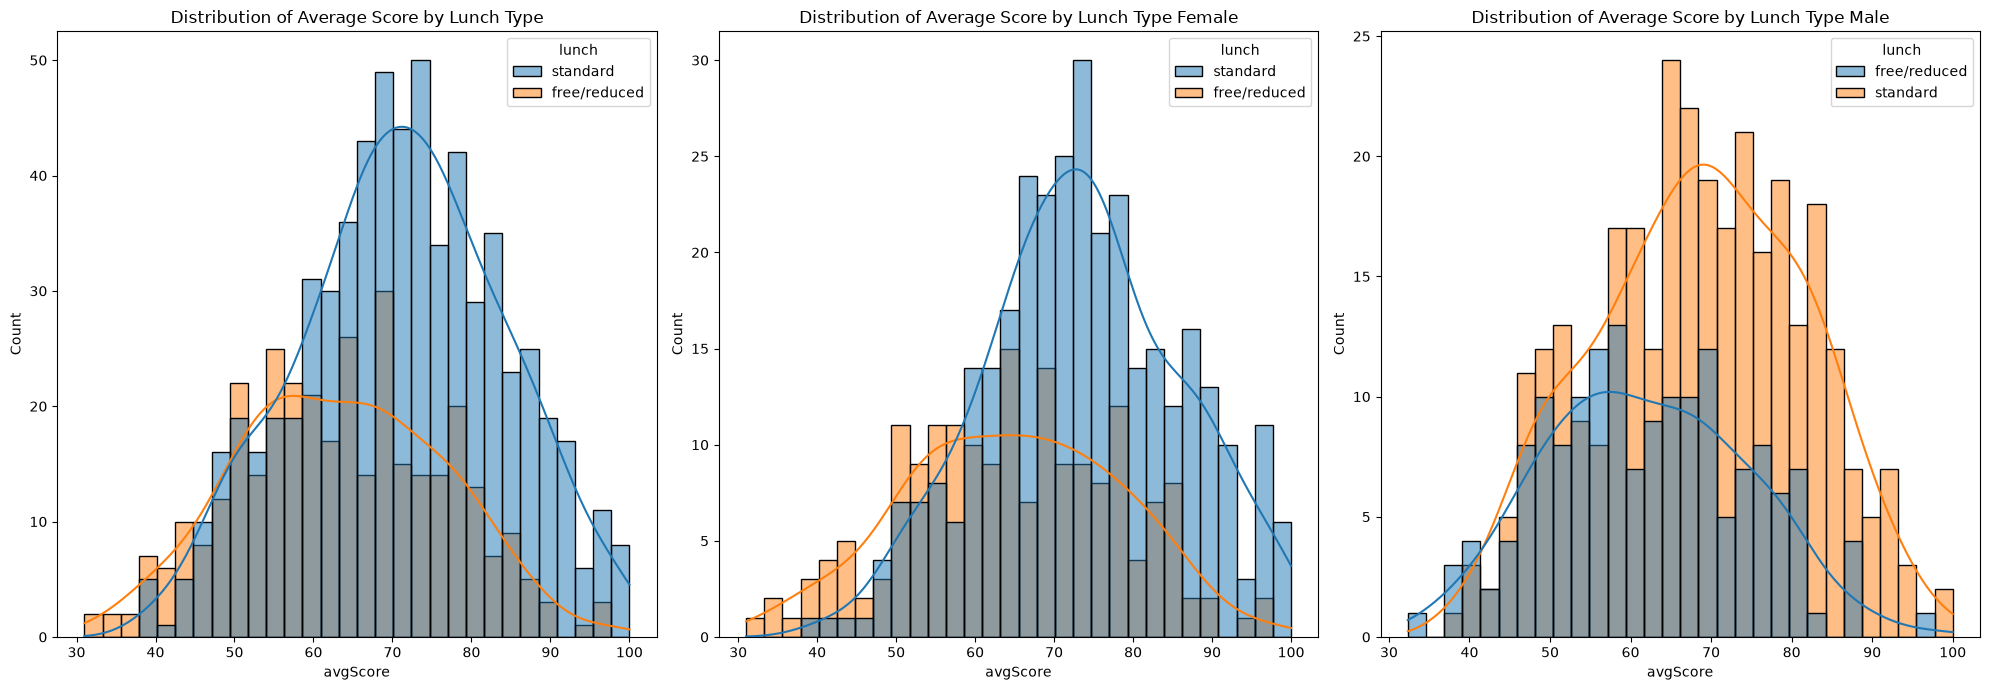

In [ ]:
# Visualizing the distribution of average scores by lunch type

plt.subplots(1,3,figsize=(20,7))

plt.subplot(131)
sns.histplot(data=df,x='avgScore',kde=True,bins=30,color='green',hue='lunch')
plt.title('Distribution of Average Score by Lunch Type')

plt.subplot(132)
sns.histplot(data=df[df['gender']=='female'],x='avgScore',kde=True,bins=30,hue='lunch')
plt.title('Distribution of Average Score by Lunch Type Female')

plt.subplot(133)
sns.histplot(data=df[df['gender']=='male'],x='avgScore',kde=True,bins=30,hue='lunch')
plt.title('Distribution of Average Score by Lunch Type Male')

plt.tight_layout()
plt.show()